# Modelo de velocidade OpenFWI com Deepwave

Esse notebook busca replicar a geometria de aquisição de um modelo de velocidade do datset OpenFWI usando o módulo Deepwave.

In [1]:
import torch
import matplotlib.pyplot as plt
import deepwave
from deepwave import scalar
import numpy as np
import matplotlib.pyplot as plt

import vis
import os   

W0707 22:32:23.124000 286376 site-packages/torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0707 22:32:23.124000 286376 site-packages/torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


In [2]:
# device = torch.device('cpu')
# Device Configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Buscamos replicar a geometria de aquisição descrita no [artigo do OpenFWI](https://arxiv.org/abs/2111.02926v6) para os conjuntos `FlatFault_A` e `FlatVel_A`.

<img src="geometria-de-aquisicao-vel-fault.png" alt="Geometria de aquisição" width="1000">

Usaremos essas informações na modelagem do Deepwave na tentativa de reproduzir os dados sísmicos.

## Carregando FlatVel_A

In [3]:
# Escolha o índice do arquivo (ex.: 1, 28, 120, ...)
model_idx = 28
sample = 0

data_path = f'openfwi-examples/FlatVel_A/data/data{model_idx}.npy'
model_path = f'openfwi-examples/FlatVel_A/model/model{model_idx}.npy'

# load seismic data
seismic_data = np.load(data_path)
print(f'Seismic Data Loaded: data{model_idx}')
print(f'Data path: {data_path}')
print(f'Data shape: {seismic_data.shape}')

# load velocity map
velocity_map = np.load(model_path)
print(f'\nVelocity Map Loaded: model{model_idx}')
print(f'Model path: {model_path}')
print(f'Model shape: {velocity_map.shape}')

Seismic Data Loaded: data28
Data path: openfwi-examples/FlatVel_A/data/data28.npy
Data shape: (500, 5, 1000, 70)

Velocity Map Loaded: model28
Model path: openfwi-examples/FlatVel_A/model/model28.npy
Model shape: (500, 1, 70, 70)


Pelo shape dos dados, verificamos que:

---

1. Velocity Map (`model*`)

**Shape:** `(500, 1, 70, 70)`

Este é o modelo de velocidades da subsuperfície, que gera os dados sísmicos.

* **1:** Número de **canais (channels)**. Como a velocidade é uma propriedade escalar única para cada ponto do espaço, há apenas 1 canal.
* **70:** Dimensão espacial $X$ (largura do modelo).
* **70:** Dimensão espacial $Y$ (comprimento/profundidade do modelo).

> A tabela diz que o **Velocity Map Spatial Size** é de $0.7 \times 0.7\text{ km}^2$ ($700 \times 700\text{ m}$) e o **Grid Spacing** (espaçamento da malha) é de $10\text{ m}$. Dividindo o tamanho total pelo espaçamento ($\frac{700\text{ m}}{10\text{ m}}$), chegamos exatamente a **70 pontos de grade** por eixo.

---

2. Seismic Data (`data*`)

**Shape:** `(500, 5, 1000, 70)`

Estes são os dados sísmicos de reflexão registrados na superfície (os tiros e os traços recebidos).

* **5:** Número de **fontes sísmicas (shots)** por modelo.
> A tabela mostra que a **Source Line Length** é de $0.7\text{ km}$ ($700\text{ m}$) e o **Source Spacing** (distância entre os tiros) é de $140\text{ m}$. Se dividirmos $\frac{700}{140}$, temos exatamente **5 posições de tiro** ao longo da linha.


* **1000:** Número de **amostras temporais** por traço sísmico.
> O **Recorded Time** (tempo de gravação) é de $1\text{ s}$ e o **Time Spacing** (taxa de amostragem temporal) é de $0.001\text{ s}$ ($1\text{ ms}$). Dividindo o tempo total pelo intervalo ($\frac{1\text{ s}}{0.001\text{ s}}$), obtemos exatamente **1000 amostras de tempo**.


* **70:** Número de **receptores (geofones/hidrofones)** registrando cada tiro.
> A **Receiver Line Length** é de $0.7\text{ km}$ ($700\text{ m}$) e o **Receiver Line Spacing** é de $10\text{ m}$. Dividindo a linha pelo espaçamento ($\frac{700\text{ m}}{10\text{ m}}$), temos exatamente **70 receptores** dispostos na superfície.

Isso significa que, para cada um dos 500 cenários geológicos, você tem um experimento sísmico com **5 tiros diferentes**, onde cada tiro gerou um sismograma contendo **70 traços** (receptores), e cada traço tem **1000 pontos de tempo** de duração.

Podemos visualizar esses dados. Fixamos um modelo presente no arquivo selecionado para trabalhar.

In [4]:
def plot_velocity_model(model_tensor, sample_idx, path=None):
    """
    Plota o mapa de velocidade de um sample específico com os eixos baseados na geometria real.
    
    Parameters:
    - model_tensor: O tensor completo de velocidades (ex: shape 500, 1, 70, 70)
    - sample_idx: O índice do modelo que você deseja plotar (de 0 a 499)
    - path: Caminho para salvar a imagem (opcional)
    - rainbow_cmap: Colormap para o plot (padrão 'jet')
    """

    # Load colormap for velocity map visualization
    from matplotlib.colors import ListedColormap
    rainbow_cmap = ListedColormap(np.load('rainbow256.npy'))

    # 1. Extrai o sample e remove as dimensões extras para ficar 2D (70, 70)
    label = np.squeeze(model_tensor[sample_idx])
    
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    vmax, vmin = np.max(label), np.min(label)
    im = ax.matshow(label, cmap=rainbow_cmap, vmin=vmin, vmax=vmax)

    # Dimensões da tabela
    grid_spacing = 10       # 10 metros por pixel
    max_distance = 700      # 0.7 km = 700 metros
    tick_step_meters = 140  # Passo dos ticks em metros (ex: 0, 140, 280...)
    
    # Conversão de metros para índices da matriz (pixels)
    tick_step_pixels = tick_step_meters / grid_spacing # 140 / 10 = 14 pixels
    max_pixels = label.shape[0]                        # 70 pixels
    
    # Criando a lista de posições (pixels) e labels (metros)
    ticks_pixels = np.arange(0, max_pixels + 1, tick_step_pixels)
    ticks_meters = np.arange(0, max_distance + 1, tick_step_meters)
    
    # Configuração dos eixos
    ax.set_aspect(aspect=1)
    ax.set_xticks(ticks_pixels)
    ax.set_xticklabels(ticks_meters)
    ax.set_yticks(ticks_pixels)
    ax.set_yticklabels(ticks_meters)
    
    # Títulos e legendas
    ax.set_title('Distance (m)', y=1.08)
    ax.set_ylabel('Depth (m)', fontsize=18)

    fig.colorbar(im, ax=ax, shrink=1.0, label='Velocity (m/s)')
    
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f"Imagem salva em: {path}")
    
    plt.show()

Imagem salva em: outputs/FlatVel_A/model_plot_sample0.png


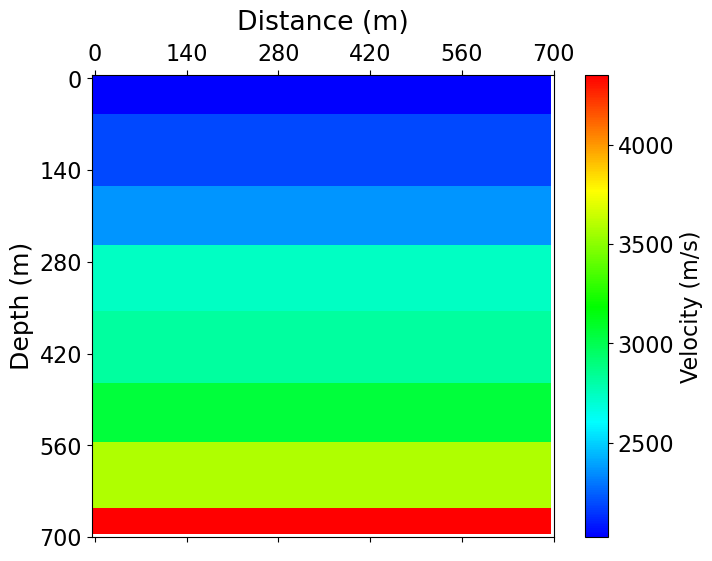

In [5]:
plot_velocity_model(velocity_map, sample, path=f"outputs/FlatVel_A/model_plot_sample{sample}.png")

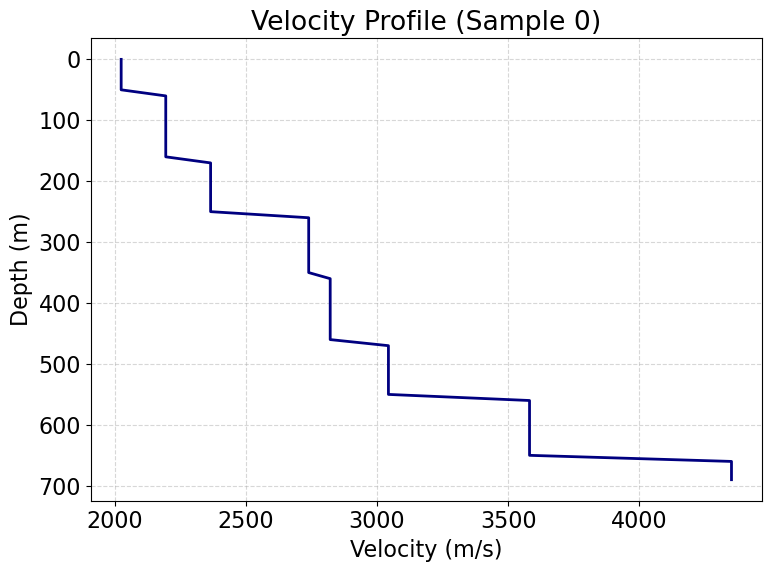

In [6]:
profile = velocity_map[sample, 0, :, 1]  # Perfil de velocidade na coluna 1 (x=10m)
depth_m = np.arange(len(profile)) * 10  # Profundidade em metros (10m por pixel)

plt.figure(figsize=(8, 6))
plt.plot(profile, depth_m, linewidth=2, color='navy')
plt.gca().invert_yaxis()  # Inverte o eixo Y para que a profundidade aumente para baixo
plt.title(f'Velocity Profile (Sample {sample})')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Depth (m)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
def plot_5_shots(seismic_data, sample, path=None):
    # Se o dado vier com o shape completo (500, 5, 1000, 70), extraímos o sample
    if seismic_data.ndim == 4:
        data_sample = seismic_data[sample] # Shape resultante: (5, 1000, 70)
    else:
        data_sample = seismic_data
        
    nz, nx = data_sample[0].shape # 1000 amostras de tempo, 70 receptores
    
    plt.rcParams.update({'font.size': 11})
    
    # Criamos 1 linha e 5 colunas para os 5 tiros (shots)
    fig, axes = plt.subplots(1, 5, figsize=(18, 6))
    
    # --- Parâmetros baseados na tabela de aquisição ---
    # Eixo X: Receptores (0 a 700 metros, passo de 140m)
    dx = 10                  # Espaçamento dos receptores = 10m
    tick_step_x_meters = 140 # Passo do marcador em metros
    ticks_x_pixels = np.arange(0, nx + 1, tick_step_x_meters / dx)
    labels_x_meters = np.arange(0, 700 + 1, tick_step_x_meters)
    
    # Eixo Y: Tempo (0 a 1000 ms, passo de 200 ms)
    dt = 1                   # Espaçamento temporal = 1ms (0.001s)
    tick_step_y_ms = 200     # Passo do marcador em milissegundos
    ticks_y_pixels = np.arange(0, nz + 1, tick_step_y_ms / dt)
    labels_y_ms = np.arange(0, 1000 + 1, tick_step_y_ms)
    # -------------------------------------------------

    for i in range(5):
        ax = axes[i]
        shot_data = data_sample[i]
        
        # Escala de ganho (0.01 do valor máximo/mínimo)
        vmin, vmax = np.min(shot_data), np.max(shot_data)
        
        # 'aspect=auto' permite que o matplotlib estique a imagem para preencher o gráfico
        im = ax.matshow(shot_data, aspect='auto', cmap='gray', 
                        vmin=vmin * 0.01, vmax=vmax * 0.01)
        
        # Força o aspecto visual correto baseado nas proporções da matriz
        ax.set_aspect(aspect=nx/nz)
        
        # Configuração do Eixo X (Offset) para todos os plots
        ax.set_xticks(ticks_x_pixels)
        ax.set_xticklabels(labels_x_meters)
        ax.set_title(f'Shot {i+1}\nDistance (m)', y=1.08, fontsize=12, fontweight='bold')
        
        # Configuração do Eixo Y (Time) - Apenas no primeiro gráfico para evitar poluição visual
        ax.set_yticks(ticks_y_pixels)
        if i == 0:
            ax.set_yticklabels(labels_y_ms)
            ax.set_ylabel('Time (ms)', fontsize=13)
        else:
            ax.set_yticklabels([]) # Remove os números nos tiros subsequentes

    # Ajusta o espaçamento para a colorbar não sobrepor os gráficos
    fig.subplots_adjust(right=0.88, wspace=0.3)
    cbar_ax = fig.add_axes([0.91, 0.25, 0.015, 0.5]) # [esquerda, baixo, largura, altura]
    fig.colorbar(im, cax=cbar_ax, label='Amplitude')

    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f"Sismograma salvo em: {path}")

    plt.show()

Sismograma salvo em: outputs/FlatVel_A/seismic_plot_sample0.png


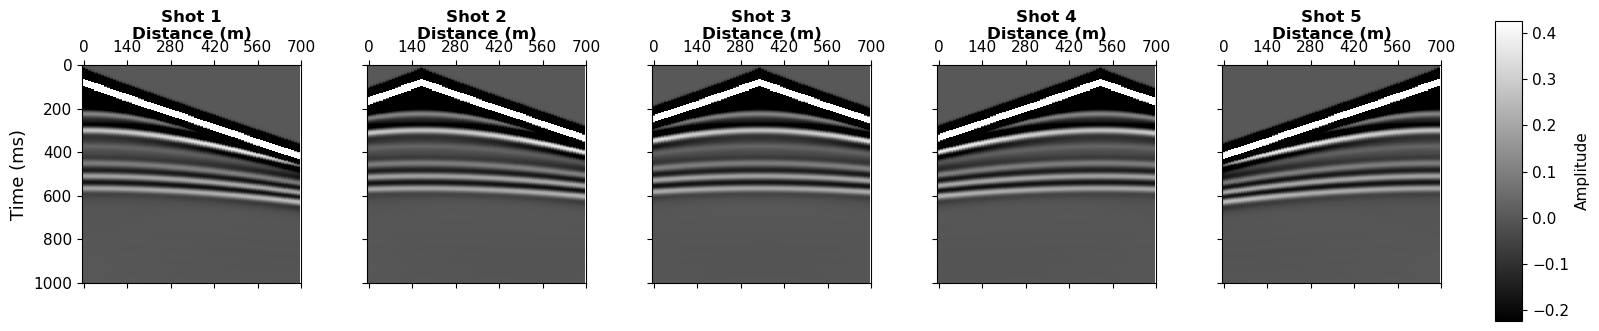

In [8]:
plot_5_shots(seismic_data, sample, path=f"outputs/FlatVel_A/seismic_plot_sample{sample}.png")

## Replicando `data` com Deepwave

In [9]:
# --- Parâmetros Sísmicos (Baseados no seu JSON) ---
dx = 10.0          # Espaçamento da grade (m) -> Alterado de 4.0 para 10.0 (conforme 'dx': 10)
dt = 1e-3          # Intervalo de tempo (s) -> Alterado para 0.001 (conforme 'dt': 1e-3)
nt = 1000          # Número de passos de tempo -> Alterado para 1000 (conforme 'nt': 1000)
peak_freq = 15     # Frequência central (Hz) -> Alterado para 15 (conforme 'f': 15)
num_dims = 2       # Modelagem 2D

# --- Geometria de Aquisição (Baseados no seu JSON) ---
num_shots = 5                 # Número de fontes/tiros -> Alterado de 3 para 5 (conforme 'ns': 5)
num_sources_per_shot = 1      # 1 fonte por tiro
num_receivers_per_shot = 70   # Número de receptores -> Alterado de 384 para 70 (conforme 'ng': 70)

# Espaçamentos físicos em metros
receiver_spacing_m = 10       # Distância em metros entre receptores (geralmente igual ao dx)
first_receiver_m = 0          # Posição X em metros do primeiro receptor

first_source_m = 0            # Posição X em metros do primeiro tiro
source_spacing_m = np.zeros(num_shots)
source_spacing_m[0] = 0
source_spacing_m[1] = 170   
source_spacing_m[2] = 340
source_spacing_m[3] = 520
source_spacing_m[4] = 690

# Profundidades em metros (Convertidas de 'sz': 10 e 'gz': 10 da grade -> 10 * 10m = 100m)
source_depth_m = 10          
receiver_depth_m = 10        

# --- Conversão de Metros para Índices da Grade (Essencial para o Deepwave) ---

source_spacing =  (source_spacing_m / dx).astype(int)
receiver_spacing = int(receiver_spacing_m / dx)
first_source = int(first_source_m / dx)
first_receiver = int(first_receiver_m / dx)
source_depth = int(source_depth_m / dx)
receiver_depth = int(receiver_depth_m / dx)



# --- Criação dos Tensores de Posição ---

# source_locations (Dimensões: [num_shots, num_sources_per_shot, num_dims])
source_locations = torch.zeros(num_shots, num_sources_per_shot, num_dims,
                               dtype=torch.long, device=device)
source_locations[..., 1] = source_depth  # Define a profundidade Z fixa
# Calcula a posição X de cada tiro ao longo da grade
source_locations[:, 0, 0] = torch.from_numpy(source_spacing).to(device)
print(f"Source Locations Tensor:\n{source_locations[:, 0, 0]}\n")
# receiver_locations (Dimensões: [num_shots, num_receivers_per_shot, num_dims])
receiver_locations = torch.zeros(num_shots, num_receivers_per_shot, num_dims,
                                 dtype=torch.long, device=device)
receiver_locations[..., 1] = receiver_depth  # Define a profundidade Z fixa
# Calcula a posição X de todos os receptores para todos os tiros
receiver_x = torch.arange(num_receivers_per_shot, device=device) * receiver_spacing + first_receiver
receiver_locations[:, :, 0] = receiver_x.repeat(num_shots, 1)


Source Locations Tensor:
tensor([ 0, 17, 34, 52, 69], device='cuda:0')



Ricker Wavelet Parameters: peak_time=0.072


/tmp/ipykernel_286376/1475057998.py:18: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4421.)
  plt.plot(time, source_amplitudes.cpu().T[:, 0, 0], label='Source signal', color='blue')


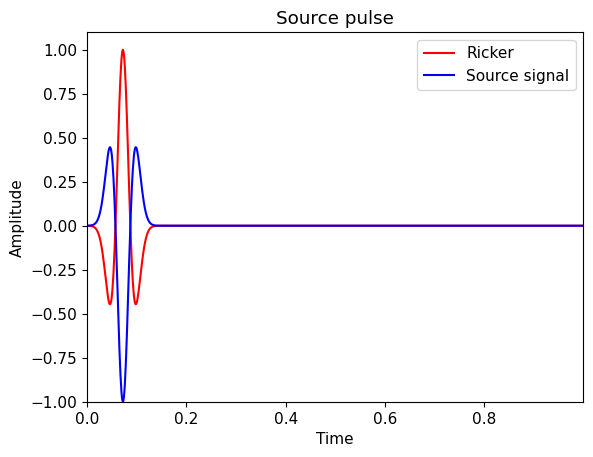

In [10]:
# --- Criando a Amplitude da Fonte (Ondaleta Ricker) ---

# O Deepwave gera a Ricker com formato [nt]. Precisamos expandir para [num_shots, num_sources, nt]
peak_time = int((1.0 / peak_freq) * nt)/nt  # Ajusta o tempo de pico para o número de amostras  
peak_time = 0.072
print(f"Ricker Wavelet Parameters: peak_time={peak_time}")
ricker_wavelet = deepwave.wavelets.ricker(peak_freq, nt, dt, peak_time)
source_amplitudes = (- ricker_wavelet
                     .repeat(num_shots, num_sources_per_shot, 1)
                     .to(device))

# Eixo temporal em milissegundos
time_ms = np.arange(nt) * dt * 1e3
time_seconds = np.arange(nt) * dt
time_samples = np.arange(nt)
time = time_seconds
plt.plot(time, ricker_wavelet.cpu(), label='Ricker', color='red')
plt.plot(time, source_amplitudes.cpu().T[:, 0, 0], label='Source signal', color='blue')
plt.ylim(-1, 1 + 0.1)
# plt.xlim(0, peak_time + 5 * dt)
plt.xlim(0, time[-1])  # Ajusta o limite do eixo X para o final do tempo
plt.title('Source pulse')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.legend()
plt.show()

In [11]:
# --- 7. Convertendo o modelo de velocidade para Tensor ---
vel = velocity_map[sample, 0, :, :]
print(np.max(vel), np.min(vel))
# vel[:,:] =  np.min(vel)
v = torch.from_numpy(vel).to(device).T

4352.0 2025.0


In [12]:
# --- 8. Propagação da Onda (Forward Modeling) ---
out = deepwave.scalar(
    v, 
    grid_spacing=dx,
    dt=dt,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    accuracy=8,
    pml_freq=peak_freq,pml_width=[50,50,50,50]
)

# O dado sísmico gravado estará em out[-1]
data = out[-1]
print(f"Shape do dado simulado: {data.shape}")

Shape do dado simulado: torch.Size([5, 70, 1000])


In [13]:
# save modeled data to file
np.save(f'outputs/FlatVel_A/seismic_data_simulated_sample{sample}.npy', data.cpu().numpy())

Shape modificado do dado simulado: (5, 1000, 70)
Sismograma salvo em: outputs/FlatVel_A/seismic_plot_simulated_sample0.png


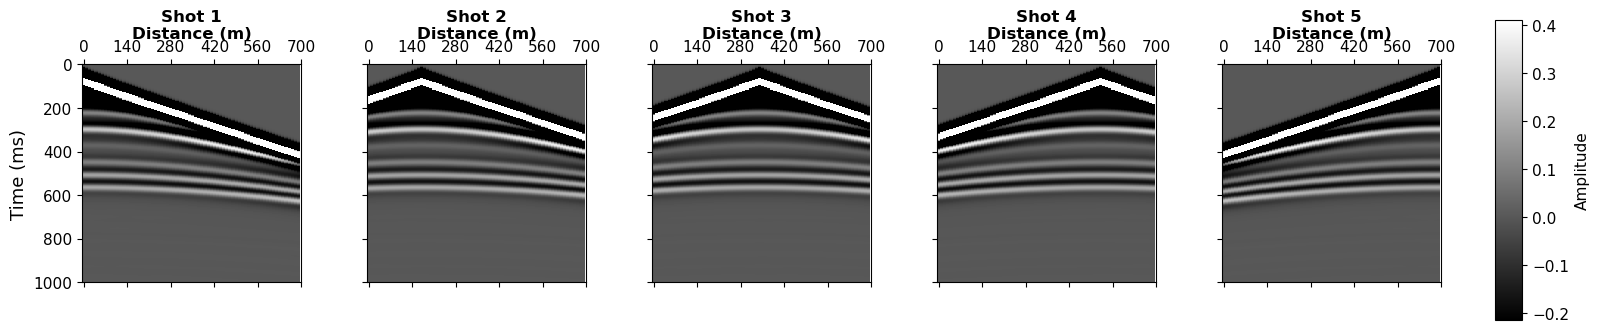

Sismograma salvo em: outputs/FlatVel_A/seismic_plot_sample0.png


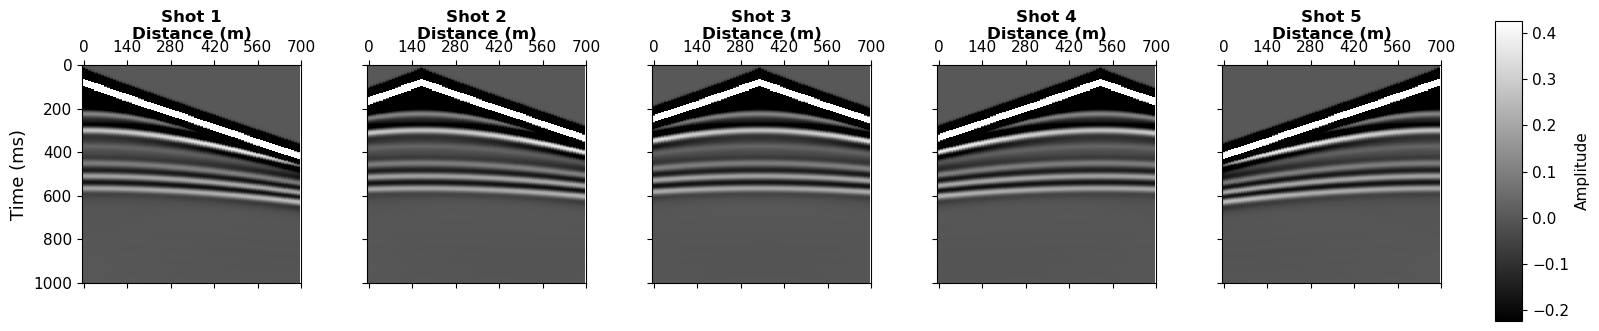

In [14]:
datanpy = data.permute(0, 2, 1).cpu().numpy()
print(f"Shape modificado do dado simulado: {datanpy.shape}")
plot_5_shots(datanpy, sample, path=f"outputs/FlatVel_A/seismic_plot_simulated_sample{sample}.png")
plot_5_shots(seismic_data, sample, path=f"outputs/FlatVel_A/seismic_plot_sample{sample}.png")

In [ ]:
# output = np.empty((nt, num_shots * num_receivers_per_shot), dtype=np.float32)

# # Write true data
# for shot in range(num_shots):
#     j0 = shot * num_receivers_per_shot
#     j1 = j0 + num_receivers_per_shot
#     output[:, j0:j1] = seismic_data[sample,shot,:,:]

# # Transpose before writing so the binary layout matches Fortran column-major
# # ordering expected by the Seismic Unix (SU) utilities.
# output.T.tofile("data_true.bin")

# # Reuse the same array for modeled data
# for shot in range(num_shots):
#     j0 = shot * num_receivers_per_shot
#     j1 = j0 + num_receivers_per_shot
#     output[:, j0:j1] = datanpy[shot,:,:]

# # Transpose before writing so the binary layout matches Fortran column-major
# # ordering expected by the Seismic Unix (SU) utilities.
# output.T.tofile("data_model.bin")

# # Reuse the same array for residual data 
# for shot in range(num_shots):
#     j0 = shot * num_receivers_per_shot
#     j1 = j0 + num_receivers_per_shot
#     output[:, j0:j1] = seismic_data[sample,shot,:,:] - datanpy[shot,:,:]

# # Transpose before writing so the binary layout matches Fortran column-major
# # ordering expected by the Seismic Unix (SU) utilities.
# output.T.tofile("data_res.bin")

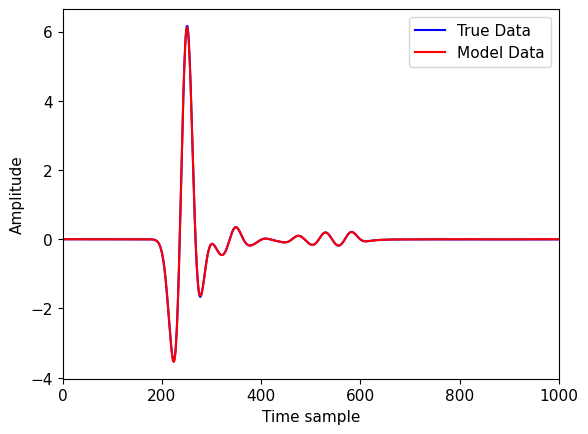

In [16]:
shot=0
trace=35
trace_true = seismic_data[sample,shot,:, trace]
trace_model = datanpy[shot,:, trace]

plt.plot(trace_true, label='True Data', color='blue')
plt.plot(trace_model, label='Model Data', color='red')
plt.legend()
plt.xlim(0, nt) 
plt.ylabel('Amplitude')
plt.xlabel('Time sample')
plt.show()